Connected to .venv (Python 3.14.5)

 # Third-party API Comparison

 In this notebook, we compare the ||`aidweather` NASA POWER API tool
 across multiple time-series datasets.

 ## 1. Weather Data Sources

 We select alternative data sources to fetch overlapping data for the same geographical coordinates and time range.

 * **Meteostat:** Historical observation data aggregating national weather services.
 * **Open-Meteo:** Lightning-fast open-source weather API delivering ERA5 historical data.

 ## 2. Recommended Python Stack

 * `pandas`, `numpy`: Data manipulation.
 * `scikit-learn`: Validation metrics (MAE, RMSE).
 * `matplotlib` / `seaborn`: Visualization.
 * `openmeteo-requests`: Official Open-Meteo client.

In [ ]:
import os
import pathlib
from datetime import datetime

import matplotlib.pyplot as plt

# Third-party data clients
import meteostat as ms
import numpy as np
import openmeteo_requests
import pandas as pd
import requests
import requests_cache
import seaborn as sns
from retry_requests import retry

import sys

# ---------------------------------------------------------------------------
# Execution-context detection
# ---------------------------------------------------------------------------
try:
    _ipy = get_ipython()  # type: ignore[name-defined]
    IS_NOTEBOOK = _ipy is not None
except NameError:
    IS_NOTEBOOK = False

_SCRIPT_DIR = pathlib.Path(__file__).resolve().parent if not IS_NOTEBOOK else pathlib.Path(".").resolve()
if _SCRIPT_DIR.name in ("scripts", "notebooks"):
    _VALIDATION_DIR = _SCRIPT_DIR.parent
else:
    _VALIDATION_DIR = _SCRIPT_DIR

_WORKSPACE_DIR = _VALIDATION_DIR.parent.parent
sys.path.insert(0, str(_WORKSPACE_DIR / "src"))

try:
    from aidweather import PowerClient
except ImportError:
    from src.aidweather import PowerClient  # type: ignore[no-redef]

PLOT_DIR = _VALIDATION_DIR / "plots"
if not IS_NOTEBOOK:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"📁 Plots will be saved to: {PLOT_DIR.resolve()}")


def save_or_show(filename: str) -> None:
    """Save figure to PLOT_DIR when running as a script, show inline otherwise."""
    if IS_NOTEBOOK:
        plt.show()
    else:
        out_path = PLOT_DIR / filename
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"💾 Saved: {out_path}")

 ## 3. Location & Configuration

 **Brasília (DF) - Brazil:** An excellent choice for testing due to its high density of stable INMET stations and distinct seasonal regimes (tropical savanna).

In [ ]:
# Configuration
lat, lon = -15.7975, -47.8919  # Brasília coordinates
start, end = datetime(2025, 1, 1), datetime(2025, 12, 31)
date_index = pd.date_range(start=start, end=end, freq="D")

print(f"Latitude: {lat} | Longitude: {lon}")
print(f"Date start: {start} | Date end: {end}")

# Master list to hold all dataframes before joining
dataframes = []

Latitude: -15.7975 | Longitude: -47.8919
Date start: 2025-01-01 00:00:00 | Date end: 2025-12-31 00:00:00


 ## 4. Data Acquisition Workflows

 ### A. AidWeather (Your Package)

In [ ]:
try:
    client = PowerClient(temporal_api="daily")
    df_aidweather = client.get_point_data(
        lat=lat, lon=lon, start=start, end=end, params=["T2M"]
    )
    df_aidweather.rename(columns={"T2M": "T2M_AIDWEATHER"}, inplace=True)
    dataframes.append(df_aidweather[["T2M_AIDWEATHER"]])
    print("✅ AidWeather fetched successfully.")
except Exception as e:
    print(f"❌ AidWeather failed: {e}")

✅ AidWeather fetched successfully.


 ### B. Meteostat

In [ ]:
try:
    point = ms.Point(lat, lon)
    stations = ms.stations.nearby(point, limit=4)
    ts = ms.daily(stations, start, end)
    df_meteostat = ms.interpolate(ts, point).fetch()
    df_meteostat = df_meteostat[["temp"]].rename(columns={"temp": "T2M_METEOSTAT"})
    dataframes.append(df_meteostat)
    print("✅ Meteostat fetched successfully.")
except Exception as e:
    print(f"❌ Meteostat failed: {e}")

✅ Meteostat fetched successfully.


 ### C. NASA POWER (Direct API)

In [ ]:
try:
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M",
        "community": "ag",
        "latitude": lat,
        "longitude": lon,
        "start": start.strftime("%Y%m%d"),
        "end": end.strftime("%Y%m%d"),
        "format": "JSON",
    }
    response = requests.get(url, params=params).json()
    nasa_data = response["properties"]["parameter"]["T2M"]
    df_nasa = pd.DataFrame.from_dict(nasa_data, orient="index", columns=["T2M_NASA"])
    df_nasa.index = pd.to_datetime(df_nasa.index, format="%Y%m%d")
    dataframes.append(df_nasa)
    print("✅ NASA POWER fetched successfully.")
except Exception as e:
    print(f"❌ NASA POWER failed: {e}")

✅ NASA POWER fetched successfully.


 ### D. Open-Meteo (Historical Archive API)

In [ ]:
try:
    # Setup cache and retry mechanism
    cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start.strftime("%Y-%m-%d"),
        "end_date": end.strftime("%Y-%m-%d"),
        "daily": "temperature_2m_mean",
        "timezone": "America/Sao_Paulo",
    }

    responses = openmeteo.weather_api(url, params=params)
    daily = responses[0].Daily()
    daily_t2m = daily.Variables(0).ValuesAsNumpy()

    df_openmeteo = pd.DataFrame({"T2M_OPENMETEO": daily_t2m}, index=date_index)
    dataframes.append(df_openmeteo)
    print("✅ Open-Meteo fetched successfully.")
except Exception as e:
    print(f"❌ Open-Meteo failed: {e}")

✅ Open-Meteo fetched successfully.


 ## 5. Comparison & Metrics Integration

In [ ]:
# Master inner join of all populated dataframes
comparison = dataframes[0].join(dataframes[1:], how="inner")

# Calculate summary statistics for all sources
print("=== Summary Statistics for Weather Data Sources ===")
print(comparison.describe().T[["mean", "std", "min", "max"]])

# Print the Pearson correlation matrix
print("\n=== Pearson Correlation Matrix ===")
print(comparison.corr())

=== Summary Statistics for Weather Data Sources ===
                     mean       std        min        max
T2M_AIDWEATHER  23.903589  2.203559      18.28      29.65
T2M_METEOSTAT   21.940548  2.109971       17.3       28.0
T2M_NASA        23.903589  2.203559      18.28      29.65
T2M_OPENMETEO   22.317575  1.923163  17.143747  27.908333

=== Pearson Correlation Matrix ===
                T2M_AIDWEATHER  T2M_METEOSTAT  T2M_NASA  T2M_OPENMETEO
T2M_AIDWEATHER        1.000000       0.873892  1.000000       0.857592
T2M_METEOSTAT         0.873892       1.000000  0.873892       0.944913
T2M_NASA              1.000000       0.873892  1.000000       0.857592
T2M_OPENMETEO         0.857592       0.944913  0.857592       1.000000


 ## 6. Data Visualization

 ### Comprehensive Time-Series Overlay

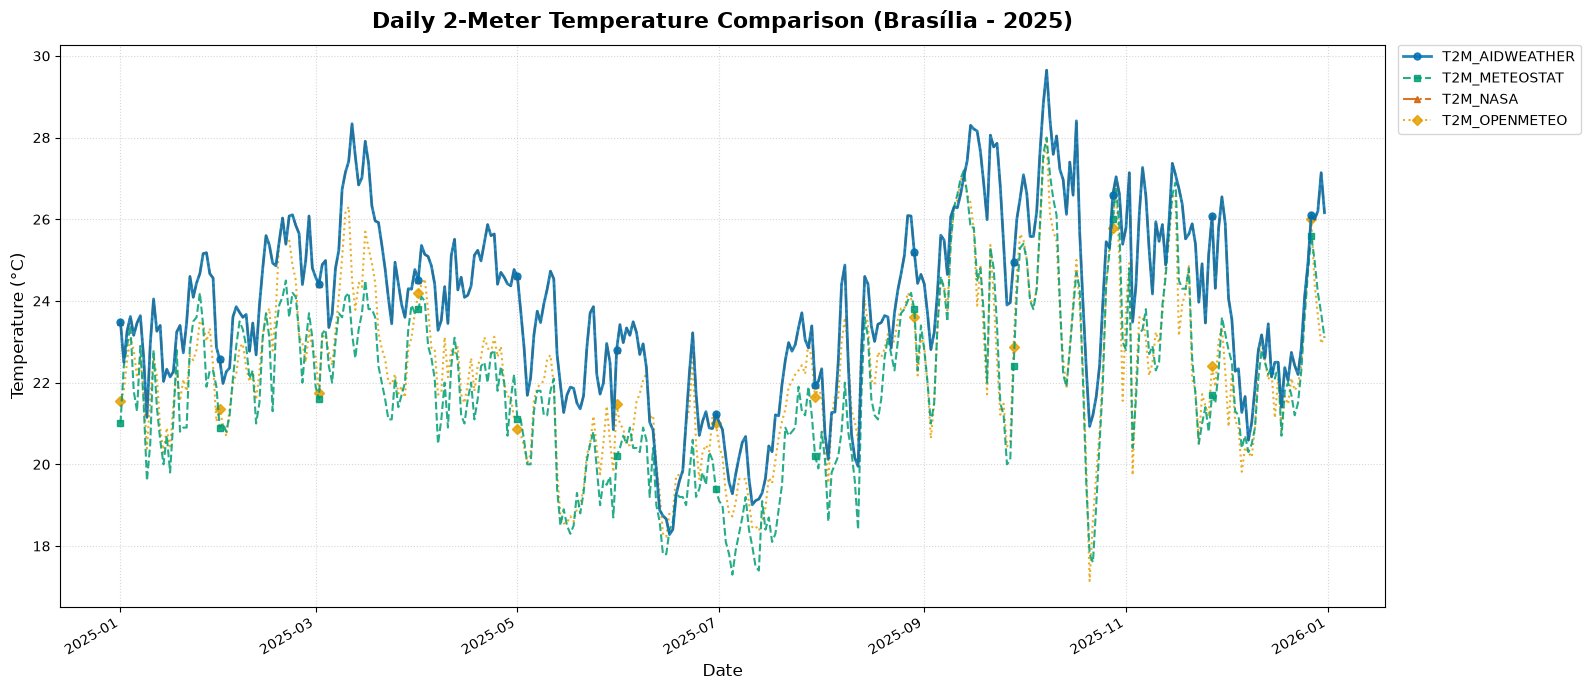

In [ ]:
# Visually distinct style cycle: color + linestyle + marker shape
# Colors chosen from the Okabe-Ito colorblind-safe palette.
_SOURCE_STYLES: list[dict] = [
    {
        "color": "#0072B2",
        "linestyle": "-",
        "marker": "o",
        "linewidth": 2.0,
    },  # blue (solid for aidweather)
    {"color": "#009E73", "linestyle": "--", "marker": "s", "linewidth": 1.5},  # green
    {
        "color": "#D55E00",
        "linestyle": "-.",
        "marker": "^",
        "linewidth": 1.5,
    },  # vermillion
    {"color": "#E69F00", "linestyle": ":", "marker": "D", "linewidth": 1.5},  # orange
    {"color": "#CC79A7", "linestyle": "--", "marker": "v", "linewidth": 1.5},  # purple
]

# Sparse marker spacing: one marker every ~30 data points to avoid clutter
_MARKER_EVERY = max(1, len(comparison) // 12)

fig, ax = plt.subplots(figsize=(16, 7))

# Plot all weather sources — each with a unique style from our palette/style list
for i, col in enumerate(comparison.columns):
    style = _SOURCE_STYLES[i % len(_SOURCE_STYLES)]
    ax.plot(
        comparison.index,
        comparison[col],
        label=col,
        color=style["color"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        markevery=_MARKER_EVERY,
        markersize=5,
        linewidth=style["linewidth"],
        alpha=0.85,
        zorder=10 - i,
    )

ax.set_title(
    "Daily 2-Meter Temperature Comparison (Brasília - 2025)",
    fontsize=16,
    fontweight="bold",
    pad=12,
)
ax.set_ylabel("Temperature (°C)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=10)
ax.grid(True, linestyle=":", alpha=0.5)
fig.autofmt_xdate()
plt.tight_layout()
save_or_show("timeseries_comparison.png")

 ### Correlation Heatmap

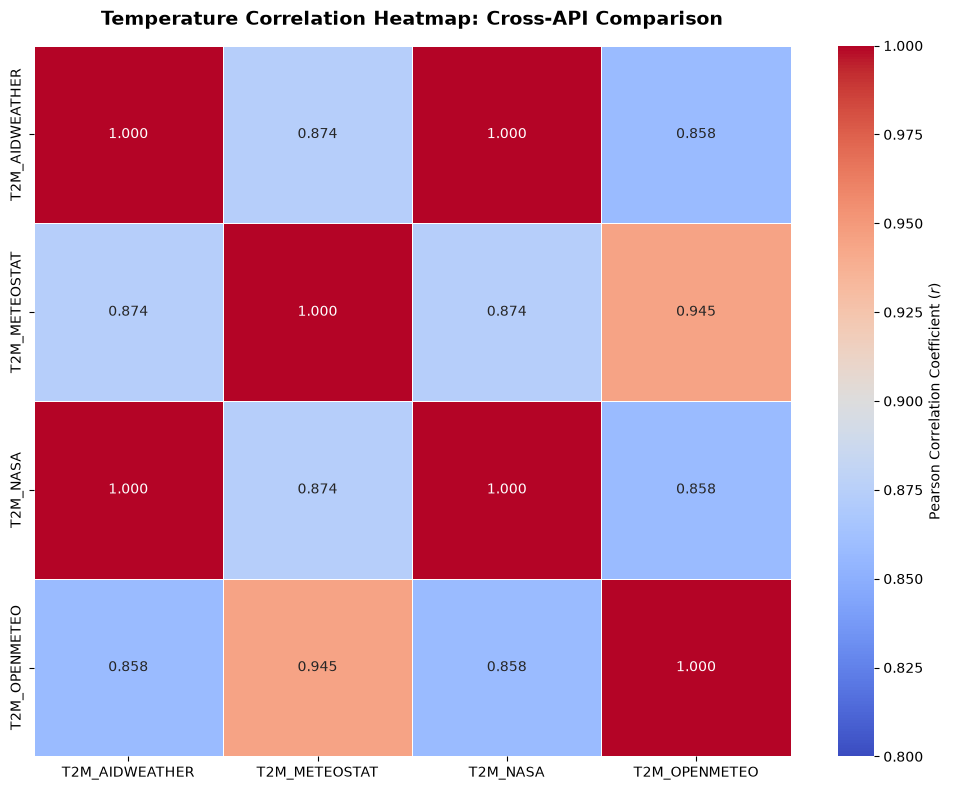

In [ ]:
corr_matrix = comparison.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    vmin=0.8,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient ($r$)"},
)
plt.title(
    "Temperature Correlation Heatmap: Cross-API Comparison",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
save_or_show("correlation_heatmap.png")